<a href="https://colab.research.google.com/github/zhabibi-z/C/blob/main/Neural_Networks_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Networks from Scratch (90 minutes)

This **one notebook** is the whole workshop. It runs in **Google Colab** or local Jupyter. You do not need any other file.

**How it is laid out**

| Part | What it is | How to read it |
| --- | --- | --- |
| Setup | install + imports | run it |
| **A. Training script** | init → forward → loss → backward → update, then `fit()` | read this top to bottom; a working network in ~110 lines |
| **B. Synthetic data** | two datasets generated by code, with a known answer | skim it — but read the generating rule, you will need it in Lab 3 |
| **C. Labs 1–3** | exercises that call the Part A functions | where you spend most of the time |

Part A only *defines* things, so nothing happens until Part B makes data and Part C starts training. If you want to know how a neural network works, Part A is the only section you have to read.

**Privacy / isolation**
- Both datasets are **generated by `numpy` inside this notebook**. Nothing is downloaded, loaded, or uploaded.
- Cells do not read or write files (`open`, `.env`, `pd.read_csv`, local folders, Drive mounts).
- Cells do not send data, credentials, or environment to any API. No model weights are downloaded.
- No company data, documents, or proprietary material of any kind belongs in this notebook. Everything the labs need is generated in Part B.

**Why no PyTorch or TensorFlow.** Both are excellent and both hide the four lines that matter. We write the gradients by hand and then *prove them correct* against finite differences in Lab 1.4. Once you have seen that, a framework is a convenience rather than a mystery.

**Colab:** File → Upload notebook → this `.ipynb` → Runtime → Run all.

| Clock | What you are doing |
| --- | --- |
| 0:00–0:15 | What a network is + setup + read Part A |
| 0:15–0:35 | Lab 1 — one neuron, then a hidden layer |
| 0:35–1:05 | Lab 2 — train on tabular data, learning curves, overfitting |
| 1:05–1:25 | Lab 3 — evaluate honestly |
| 1:25–1:30 | Wrap |

A neural network in one line: **stack simple functions, measure how wrong you are, and push every weight a little in the direction that reduces the error.**

## Setup — install packages

`numpy` does the math, `matplotlib` draws two plots. Nothing else is needed.

In [31]:
%pip install -q numpy matplotlib


## Setup — imports

No file access, no network. `SEED` is fixed so your numbers match the person next to you (tiny differences across numpy or BLAS versions are normal).

In [32]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 0
np.set_printoptions(precision=3, suppress=True)
print("Ready. numpy", np.__version__)


Ready. numpy 2.0.2


---

# Part A — the training script

Training a network is a loop over five steps:

```
initialize → forward → loss → backward → update      fit() runs the loop
```

`forward` turns inputs into a prediction. `loss` scores how wrong it is. `backward` computes
how much each weight contributed to that wrongness. `update` nudges every weight downhill.
Repeat.

Every cell in this part **defines** a function. Nothing runs against data until Part B.

## A.1 Data shapes, and the one rule about scaling

Conventions used everywhere below:

- `X` is `(n_samples, n_features)`, float
- `y` is `(n_samples,)`, containing `0.0` or `1.0` — this notebook does binary classification
- a prediction is one number per row: the **logit**, which becomes a probability via the sigmoid

Neural networks are sensitive to feature scale: a column measured in tens of thousands will
dominate a column measured in single digits, purely because of the size of the numbers. So we
standardise every column to mean 0, standard deviation 1.

`Standardizer` is deliberately written as `fit` / `transform` — the same shape as the embedder in
the RAG workshop, and for the same reason. **Statistics are learned from the training split only.**
Fitting on all your data lets information from the validation and test rows leak into training, and
your score comes out flattering and wrong.

In [33]:
class Standardizer:
    """Column-wise mean 0 / std 1. fit() on train only, then transform() everything."""

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_ = np.maximum(X.std(axis=0), 1e-12)  # never divide by zero
        return self

    def transform(self, X):
        # Uses the stored training statistics - that is the whole point of the split.
        return (X - self.mean_) / self.std_


## A.2 Initialization

A network is a list of layers, and each layer is a weight matrix `W` plus a bias vector `b`.
`sizes=[4, 16, 1]` means: 4 inputs, one hidden layer of 16 units, 1 output.

Two things about the starting values:

- **Not zeros.** If every weight in a layer starts identical, every unit computes the same thing
  and receives the same gradient, so they stay identical forever. Random values break that symmetry.
- **Scaled by `sqrt(2 / n_in)`.** This is He initialization. Too large and the activations explode
  layer over layer; too small and the signal dies out. This factor keeps the variance roughly
  stable through a ReLU network.

In [34]:
def init_params(sizes, seed=SEED):
    """One [W, b] pair per layer. He-scaled random weights, zero biases."""
    rng = np.random.default_rng(seed)
    params = []
    # zip(sizes[:-1], sizes[1:]) pairs each layer's input width with its output width:
    # [4, 16, 1] becomes (4, 16) then (16, 1).
    for n_in, n_out in zip(sizes[:-1], sizes[1:]):
        # sqrt(2 / n_in) keeps activation variance stable as depth grows (He init).
        # Wider layers therefore start with SMALLER weights, since more inputs get summed.
        W = rng.normal(0.0, np.sqrt(2.0 / n_in), size=(n_in, n_out))
        # Biases can start at zero: the random W already breaks the symmetry.
        params.append([W, np.zeros(n_out)])
    return params


## A.3 Forward pass

Each layer does the same two things: an affine transform `Z = A @ W + b`, then a nonlinearity.

The nonlinearity is the entire reason depth buys you anything. `ReLU(z) = max(z, 0)` is the
default choice — it is one comparison, and its gradient is either 0 or 1, which makes the
backward pass cheap and stable. **Lab 1.3 removes it and shows the network collapse back to a
straight line**, which is the most useful thing you can know about activations.

The last layer has no activation. It returns raw **logits** — an unbounded score where negative
means "probably class 0" and positive means "probably class 1". We convert to a probability only
when we need one, for reasons in A.4.

`forward` returns the caches (`acts`, `pre`) as well as the logits, because the backward pass needs
the values each layer saw on the way in.

In [35]:
def relu(z):
    return np.maximum(z, 0.0)


def sigmoid(z):
    # Split by sign so we never call exp() on a large positive number and overflow.
    out = np.empty_like(z, dtype=np.float64)
    pos, neg = z >= 0, z < 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[neg])
    out[neg] = ez / (1.0 + ez)
    return out


def forward(params, X, activation="relu"):
    """Return (logits, activations, pre-activations). Last layer is left linear."""
    acts = [X]  # acts[i] is the input to layer i
    pre = []  # pre[i] is Z of layer i, needed for the ReLU mask in backward()
    A = X
    for i, (W, b) in enumerate(params):
        Z = A @ W + b
        pre.append(Z)
        if i < len(params) - 1:
            A = relu(Z) if activation == "relu" else Z  # "identity" = no nonlinearity
        else:
            A = Z  # output layer stays linear: these are logits
        acts.append(A)
    return acts[-1].ravel(), acts, pre


## A.4 Loss

Binary cross-entropy. For each row it is `-log(probability the model gave the correct class)`, so
a confident correct answer costs almost nothing and a confident wrong answer costs a lot.

Written directly, that formula computes `log(sigmoid(z))` and overflows for large `|z|`. The
identity below is the standard fix and is why the network passes logits around instead of
probabilities:

```
BCE(z, y) = log(1 + exp(z)) - y*z      computed as np.logaddexp(0, z) - y*z
```

`l2` adds a penalty proportional to the sum of squared weights. It pushes the network toward
smaller weights, which means smoother decision boundaries and less memorising. Lab 2.3 and Lab 3.3
measure what it buys.

In [36]:
def bce_with_logits(logits, y):
    """Mean binary cross-entropy, computed in a way that cannot overflow."""
    # logaddexp(0, z) gives log(1 + exp(z)) without ever evaluating exp(z) itself,
    # so a logit of 800 is fine here and would be inf the naive way.
    return float(np.mean(np.logaddexp(0.0, logits) - y * logits))


def total_loss(params, X, y, activation="relu", l2=0.0):
    """Data loss plus the L2 weight penalty — the quantity training actually minimises."""
    logits, _, _ = forward(params, X, activation)
    # The 0.5 is cosmetic: it makes this term's derivative exactly l2 * W, which is the
    # "+ l2 * W" you will see in backward(). Biases are deliberately not penalised.
    penalty = 0.5 * l2 * sum(float(np.sum(W * W)) for W, _ in params)
    return bce_with_logits(logits, y) + penalty


## A.5 Backward pass — the only real math here

We need the derivative of the loss with respect to every weight. Two facts make it short.

**Fact one.** For cross-entropy on top of a sigmoid, the gradient at the output collapses to
something remarkably simple:

```
dLoss/dZ_last = (predicted_probability - y) / n
```

Prediction minus truth. That is it. All the exponentials cancel.

**Fact two — the chain rule.** Once you know how the loss changes with a layer's output, you get
two things by multiplying: how it changes with that layer's weights (`A_prev.T @ dZ`), and how it
changes with the *previous* layer's output (`dZ @ W.T`). So we walk backwards through the layers,
carrying `dZ` with us.

Passing back through a ReLU means killing the gradient wherever the unit was inactive — that is
the `(pre[i-1] > 0)` mask. A unit that contributed nothing on the way forward gets no blame on the
way back.

If this feels like something you should verify rather than trust: correct. Lab 1.4 checks every
one of these derivatives against numerical differences.

In [37]:
def backward(params, acts, pre, logits, y, activation="relu", l2=0.0):
    """Gradients of the loss w.r.t. every W and b, same nested shape as params."""
    n = y.shape[0]
    grads = [[np.zeros_like(W), np.zeros_like(b)] for W, b in params]

    # Fact one: at the output, the gradient is just (probability - truth).
    dZ = ((sigmoid(logits) - y) / n).reshape(-1, 1)

    for i in reversed(range(len(params))):
        W, _ = params[i]
        grads[i][0] = acts[i].T @ dZ + l2 * W  # weight gradient (+ L2 penalty)
        grads[i][1] = dZ.sum(axis=0)  # bias gradient
        if i > 0:
            dA = dZ @ W.T  # push the error back to the previous layer's output
            # ...then back through its nonlinearity.
            dZ = dA * ((pre[i - 1] > 0) if activation == "relu" else 1.0)
    return grads


## A.6 The training loop

Now the loop. Three details worth naming:

**Mini-batches.** We do not compute the gradient on all 1,800 rows before taking a step. We shuffle
and walk through in groups of `batch_size`, updating each time. The gradient from 64 rows is noisier
than the true gradient, but you get ~28 updates per pass instead of 1, and the noise itself helps
the network escape bad spots. Exercise C measures the trade-off.

**Momentum.** Instead of stepping straight down the current gradient, we keep a running velocity.
It damps the zig-zagging that plain gradient descent does in narrow valleys, and it is three lines.

**History.** After each epoch we record loss and accuracy on train *and* validation. This is not
decoration — the gap between those two curves is how you diagnose overfitting in Lab 2.3, and you
cannot see it from a single final number.

In [38]:
def fit(X, y, hidden=(16,), epochs=120, lr=0.1, batch_size=64, l2=0.0,
        momentum=0.9, activation="relu", seed=SEED, val=None, verbose=0):
    """Train an MLP. `hidden=()` gives a plain linear model. Returns (params, history)."""
    params = init_params([X.shape[1], *hidden, 1], seed=seed)
    velocity = [[np.zeros_like(W), np.zeros_like(b)] for W, b in params]
    rng = np.random.default_rng(seed + 1)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        order = rng.permutation(X.shape[0])  # reshuffle every epoch
        for start in range(0, X.shape[0], batch_size):
            idx = order[start : start + batch_size]
            logits, acts, pre = forward(params, X[idx], activation)
            grads = backward(params, acts, pre, logits, y[idx], activation, l2)
            for (W, b), (gW, gb), v in zip(params, grads, velocity):
                v[0] = momentum * v[0] - lr * gW  # velocity, not raw gradient
                v[1] = momentum * v[1] - lr * gb
                W += v[0]  # in-place: params is mutated as we go
                b += v[1]

        history["train_loss"].append(total_loss(params, X, y, activation, l2))
        history["train_acc"].append(accuracy(params, X, y, activation))
        if val is not None:
            history["val_loss"].append(total_loss(params, val[0], val[1], activation, l2))
            history["val_acc"].append(accuracy(params, val[0], val[1], activation))
        if verbose and (epoch + 1) % verbose == 0:
            msg = f"epoch {epoch + 1:4}  train loss {history['train_loss'][-1]:.4f}"
            if val is not None:
                msg += f"   val loss {history['val_loss'][-1]:.4f}"
            print(msg)
    return params, history


## A.7 Predict and score

`fit` returns logits-producing parameters; these turn them into decisions and numbers.

Note that `predict` takes a `threshold`. A network outputs a probability, and turning that into a
yes/no is a **separate decision you own** — 0.5 is a default, not a law. Lab 3.2 sweeps it.

In [39]:
def predict_proba(params, X, activation="relu"):
    logits, _, _ = forward(params, X, activation)
    return sigmoid(logits)


def predict(params, X, activation="relu", threshold=0.5):
    # threshold is a parameter, not a constant, because 0.5 is a default and not a law.
    return (predict_proba(params, X, activation) >= threshold).astype(float)


def accuracy(params, X, y, activation="relu", threshold=0.5):
    return float((predict(params, X, activation, threshold) == y).mean())


def confusion(params, X, y, activation="relu", threshold=0.5):
    """Counts, then the two rates that accuracy hides."""
    pred = predict(params, X, activation, threshold)
    # Four counts of predicted-vs-actual. Accuracy is (tp + tn) / everything, which is how
    # it can look respectable while one of fp / fn is quietly terrible.
    tp = float(((pred == 1) & (y == 1)).sum())
    fp = float(((pred == 1) & (y == 0)).sum())
    fn = float(((pred == 0) & (y == 1)).sum())
    tn = float(((pred == 0) & (y == 0)).sum())
    # precision: of the listings we flagged, how many sold  (denominator = our prediction)
    # recall:    of the listings that sold, how many we caught (denominator = reality)
    # The guards matter at extreme thresholds, where a class can go unpredicted entirely.
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    return {"tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "precision": precision, "recall": recall}


---

# Part B — synthetic data

Two datasets, both **generated by code in this notebook**. Nothing is read from disk or downloaded.

Generating our own data buys something you almost never have in real work: we know the true rule,
exactly. That means we can ask *how close did the network get to the best possible answer* instead
of only *did the number go up*. Lab 3 cashes that in.

**Dataset 1 — two rings.** Two dimensions so we can draw it. An inner disc (class 1) inside an
outer ring (class 0). No straight line can separate them, which is the entire point of Lab 1.

**Dataset 2 — listings.** A fictional table: 3,000 invented used-car listings, four features, and
a yes/no label for whether the listing sold within 30 days. No real listing, dealer, or company is
involved — every row comes out of the random number generator below.

In [61]:
def make_two_rings(n=1200, seed=SEED):
    """Inner disc (class 1) inside an outer ring (class 0). Not linearly separable."""
    rng = np.random.default_rng(seed)
    n_in = n // 2
    # Sample in polar coordinates - a radius and an angle - then convert to x/y below.
    # Drawing x and y directly would give squares, not rings.
    r_in, r_out = rng.normal(1.0, 0.18, n_in), rng.normal(2.2, 0.22, n - n_in)
    t_in, t_out = rng.uniform(0, 2 * np.pi, n_in), rng.uniform(0, 2 * np.pi, n - n_in)
    X = np.vstack([
        np.column_stack([r_in * np.cos(t_in), r_in * np.sin(t_in)]),
        np.column_stack([r_out * np.cos(t_out), r_out * np.sin(t_out)]),
    ])
    y = np.concatenate([np.ones(n_in), np.zeros(n - n_in)])
    # Shuffle before returning: stacked class-by-class, a mini-batch could contain only
    # one class and its gradient would be badly biased.
    shuffle = rng.permutation(n)
    return X[shuffle], y[shuffle]


### The generating rule — read this one

`make_listings` builds each label from a formula we choose, then flips a weighted coin. Two features
of that formula matter for the rest of the workshop:

- **`- 2.6 * pg**2` is non-monotone.** Priced far *below* guide looks suspicious, priced far *above*
  will not sell; the sweet spot is in the middle. A model that can only draw straight lines cannot
  represent a hump.
- **`- 1.6 * pg * mk` is an interaction.** High mileage is forgivable on a cheap car and fatal on an
  expensive one. The effect of one feature depends on another.

Then `y = (rng.random(n) < p)` — the label is a *coin flip* weighted by that probability. So even a
perfect model cannot be right every time. This ceiling is real and we will measure it.

In [41]:
def make_listings(n=3000, seed=SEED):
    """Fictional listings. Returns X, y, and p_true (the probability we generated y from)."""
    rng = np.random.default_rng(seed)
    price_gap = rng.normal(0, 6, n)  # % above (+) or below (-) guide price
    mileage_k = rng.gamma(4, 15, n)  # thousands of miles
    photos = rng.integers(1, 25, n).astype(float)
    condition = rng.integers(1, 6, n).astype(float)  # 1-5, seller's own rating

    pg, mk = price_gap / 6, (mileage_k - 60) / 30  # roughly unit-scale
    ph, cd = (photos - 12) / 7, (condition - 3) / 1.4

    logit = (
        2.2
        - 2.6 * pg**2      # non-monotone: a sweet spot, not a slope
        - 1.0 * mk
        + 0.9 * ph
        + 0.7 * cd
        - 1.6 * pg * mk    # interaction: mileage matters more on a pricey car
    )
    p_true = sigmoid(logit)
    y = (rng.random(n) < p_true).astype(np.float64)  # the label is a weighted coin flip
    X = np.column_stack([price_gap, mileage_k, photos, condition])
    return X, y, p_true


FEATURES = ["price_gap_%", "mileage_k", "photos", "condition"]

# Both datasets are built right here, in memory, by the two functions above.
rings_X, rings_y = make_two_rings()
X_all, y_all, p_true = make_listings()

print("rings   :", rings_X.shape, "labels", np.unique(rings_y))
print("listings:", X_all.shape, dict(zip(FEATURES, X_all.mean(axis=0).round(1).tolist())))
print(f"sold within 30 days: {y_all.mean():.1%} of rows")


rings   : (1200, 2) labels [0. 1.]
listings: (3000, 4) {'price_gap_%': -0.2, 'mileage_k': 61.1, 'photos': 12.3, 'condition': 3.0}
sold within 30 days: 54.4% of rows


### The two numbers that bracket every result today

**The floor.** Always predicting the majority class needs no model at all. Anything that does not
beat this is worse than useless.

**The ceiling.** Because we generated the labels, we can ask what the *true* rule scores on its own
data. It is not 100% — the labels are coin flips — and no model can do better on average. This is
the Bayes rate, and having it is a luxury: in real work you are flying blind about how much
headroom is left.

In [42]:
# Floor: guess the bigger class every time, so the score is that class's share.
majority = max(y_all.mean(), 1 - y_all.mean())
# Ceiling: score the TRUE probabilities against the labels they generated. Short of 1.0
# because those labels were coin flips - the shortfall is noise, not model error.
bayes = float(((p_true >= 0.5).astype(float) == y_all).mean())

print(f"floor   — always predict the majority class : {majority:.3f}")
print(f"ceiling — the true rule, scored on its own data: {bayes:.3f}")
print(f"so the whole game today is worth {bayes - majority:.3f} of accuracy")


floor   — always predict the majority class : 0.544
ceiling — the true rule, scored on its own data: 0.822
so the whole game today is worth 0.278 of accuracy


---

# Part C — Labs 1–3

From here on, every cell **calls** the Part A functions. If something breaks, the fix is almost
always in the arguments you passed, not in the pipeline itself.

# Lab 1 — One neuron, then a hidden layer (20 min)

Goal: see with your own eyes what a hidden layer adds, and confirm the gradients are right.

We use the two rings for this, because two dimensions can be drawn and 24 dimensions cannot.

In [43]:
rings_scaler = Standardizer().fit(rings_X)
Xr = rings_scaler.transform(rings_X)


def plot_boundary(params, X, y, title, activation="relu"):
    """Colour the plane by what the model predicts, then scatter the data on top."""
    pad = 0.5
    # Build a 220x220 lattice over the data, then treat those 48,400 points as rows of X:
    # predict on all of them and reshape the answers back into a grid. That is the shading.
    xs = np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 220)
    ys = np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 220)
    gx, gy = np.meshgrid(xs, ys)
    grid = np.column_stack([gx.ravel(), gy.ravel()])
    zz = predict_proba(params, grid, activation).reshape(gx.shape)

    plt.figure(figsize=(4.6, 4.2))
    # Colour = predicted probability, so you can see confidence, not just the 0.5 line.
    plt.contourf(gx, gy, zz, levels=20, cmap="RdBu", alpha=0.75)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], s=7, c="darkred", label="class 1")
    plt.scatter(X[y == 0, 0], X[y == 0, 1], s=7, c="navy", label="class 0")
    plt.title(title, fontsize=10)
    plt.legend(fontsize=7, loc="upper right")
    plt.tight_layout()
    plt.show()


print("rings:", Xr.shape[0], "points,", f"{rings_y.mean():.0%} class 1")


rings: 1200 points, 50% class 1


### Lab 1.1 No hidden layer

`hidden=()` is a single unit reading both inputs: one weighted sum, one sigmoid. That is logistic
regression, and geometrically it can only place **one straight line** on the plane.

Watch two numbers. Accuracy lands near 0.5 — a coin flip. And the loss sits at about 0.69, which is
`log 2`: the value you get by giving up and answering "50% chance" to everything. The model is not
badly trained. It is doing the best a straight line can do.

accuracy 0.529   final loss 0.6912   (log 2 = 0.6931)


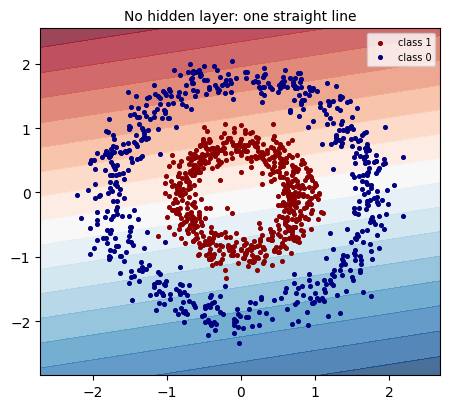

In [44]:
# hidden=() means no hidden layer at all: both inputs wired straight to one output unit.
lin_params, lin_hist = fit(Xr, rings_y, hidden=(), epochs=200, lr=0.05)

print(f"accuracy {accuracy(lin_params, Xr, rings_y):.3f}   "
      f"final loss {lin_hist['train_loss'][-1]:.4f}   (log 2 = {np.log(2):.4f})")
plot_boundary(lin_params, Xr, rings_y, "No hidden layer: one straight line")


### Lab 1.2 One hidden layer of 16 units

Identical data, identical training settings. The only change is 16 units in between.

Each hidden unit still draws one straight line. The output layer then combines them — and a
weighted sum of 16 lines, each switched on or off by a ReLU, can enclose a region. That is the
whole trick: **simple parts, composed.**

accuracy 0.998   final loss 0.0036


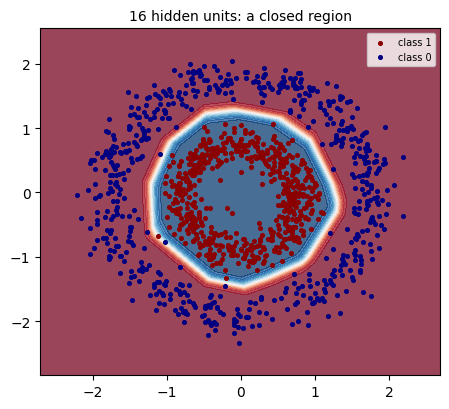

In [45]:
# Only change from the previous cell: hidden=(16,). Same data, epochs, learning rate.
mlp_params, mlp_hist = fit(Xr, rings_y, hidden=(16,), epochs=200, lr=0.05)

print(f"accuracy {accuracy(mlp_params, Xr, rings_y):.3f}   "
      f"final loss {mlp_hist['train_loss'][-1]:.4f}")
plot_boundary(mlp_params, Xr, rings_y, "16 hidden units: a closed region")


### Lab 1.3 Was it the extra parameters, or the nonlinearity?

Fair question. The hidden network has ~50 parameters against 3, so maybe capacity did the work.

Here is the test: keep all 16 units and every parameter, and only replace `ReLU` with the identity
function — pass each value through unchanged. The network is now three linear layers stacked.

It collapses straight back to a coin flip. Composing linear functions gives you another linear
function, no matter how many you stack, so the whole network mathematically *is* one straight line
again. **The nonlinearity is the ingredient. The parameters are just how many of them you get.**

relu     accuracy 0.998   loss 0.0036
identity accuracy 0.524   loss 0.6911   <- same size network, no nonlinearity


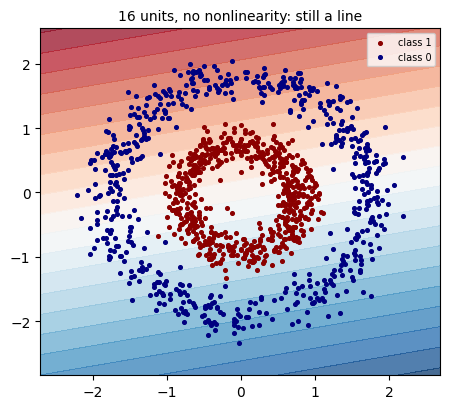

In [46]:
# Same 16 units and same parameter count - only relu is swapped for the identity.
id_params, id_hist = fit(Xr, rings_y, hidden=(16,), epochs=200, lr=0.05, activation="identity")

print(f"relu     accuracy {accuracy(mlp_params, Xr, rings_y):.3f}   "
      f"loss {mlp_hist['train_loss'][-1]:.4f}")
print(f"identity accuracy {accuracy(id_params, Xr, rings_y, activation='identity'):.3f}   "
      f"loss {id_hist['train_loss'][-1]:.4f}   <- same size network, no nonlinearity")
plot_boundary(id_params, Xr, rings_y, "16 units, no nonlinearity: still a line", activation="identity")


### Lab 1.4 Prove the gradients are right

We wrote `backward()` by hand, so it could be quietly wrong — and a subtly wrong gradient does not
crash, it just trains badly and wastes your afternoon.

There is a definitive test. The derivative of the loss with respect to one weight is, by definition,
the limit of `(loss(w + eps) - loss(w - eps)) / (2 * eps)`. So nudge each weight, measure the loss
twice, and compare that number to what `backward()` claimed.

Finite differences are far too slow for training — one forward pass per weight, and real networks
have millions. But as a *check* it is decisive. Anything below about `1e-6` here means the
derivation is correct.

In [47]:
def grad_check(sizes=(3, 5, 4, 1), n=7, eps=1e-4, per_tensor=6, seed=0):
    """Compare analytic gradients against central finite differences. Returns worst rel. error."""
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, sizes[0]))
    y = (rng.random(n) < 0.5).astype(float)
    params = init_params(list(sizes), seed=seed + 1)

    # What backward() claims the gradients are:
    logits, acts, pre = forward(params, X)
    grads = backward(params, acts, pre, logits, y)

    worst = 0.0
    for layer in range(len(params)):
        for which in (0, 1):  # 0 = W, 1 = b
            tensor = params[layer][which]
            # A few entries per tensor is plenty; each one costs two forward passes.
            for ix in list(np.ndindex(tensor.shape))[:per_tensor]:
                original = tensor[ix]  # keep it so the nudge can be undone exactly
                tensor[ix] = original + eps
                loss_up = bce_with_logits(forward(params, X)[0], y)
                tensor[ix] = original - eps
                loss_down = bce_with_logits(forward(params, X)[0], y)
                tensor[ix] = original  # always put it back

                # Central difference, more accurate than a one-sided nudge at the same eps.
                # eps is a compromise: too large and the loss curve is not locally straight,
                # too small and floating-point rounding swamps the difference.
                numeric = (loss_up - loss_down) / (2 * eps)
                analytic = grads[layer][which][ix]
                # Relative, not absolute: a gradient of 1e-8 being off by 1e-9 is fine.
                scale = max(1e-12, abs(numeric) + abs(analytic))
                worst = max(worst, abs(numeric - analytic) / scale)
    return worst


error = grad_check()
print(f"worst relative error: {error:.2e}")
print("PASS - backprop matches the numerical derivative" if error < 1e-6 else "FAIL - check backward()")


worst relative error: 3.78e-09
PASS - backprop matches the numerical derivative


### Exercise A (5 min) — how few units do you need?

The 16-unit network was overkill. Fill in the widths you want to try and find the smallest one that
separates the rings.

Think about the geometry before you run it: each hidden unit contributes one line. How many lines
does it take to fence off a disc?

In [48]:
# TODO: try some widths. Predict the answer before running.
for width in [1, 2, 4]:
    params, _ = fit(Xr, rings_y, hidden=(width,), epochs=200, lr=0.05)
    print(f"hidden={width:3}  accuracy {accuracy(params, Xr, rings_y):.3f}")


hidden=  1  accuracy 0.500
hidden=  2  accuracy 0.768
hidden=  4  accuracy 0.998


### Exercise B (5 min) — break it with the learning rate

The learning rate is the step size. Too small and training crawls; too large and each step
overshoots and the loss climbs instead of falling.

Run the cell, then read the three loss trajectories. One stalls, one works, one blows up. Learning
rate is the first thing to check when a network will not train.

In [49]:
# TODO: change these three and watch what the loss does.
for lr in [0.0005, 0.05, 20.0]:
    _, hist = fit(Xr, rings_y, hidden=(16,), epochs=60, lr=lr)
    curve = " -> ".join(f"{hist['train_loss'][i]:.3f}" for i in (0, 9, 29, 59))
    print(f"lr={lr:<8} loss over epochs 1/10/30/60:  {curve}")


lr=0.0005   loss over epochs 1/10/30/60:  1.215 -> 0.750 -> 0.635 -> 0.555
lr=0.05     loss over epochs 1/10/30/60:  0.561 -> 0.054 -> 0.015 -> 0.008
lr=20.0     loss over epochs 1/10/30/60:  11.596 -> 1.209 -> 1.950 -> 0.639


### Lab 1 checkpoint

1. A single unit draws one straight line — that is logistic regression
2. A hidden layer lets you compose lines into regions
3. The **nonlinearity** is what makes composition worth anything; remove it and depth is decoration
4. Hand-derived gradients should always be checked numerically once
5. Learning rate can stall or explode training regardless of architecture

---

# Lab 2 — Train on tabular data (30 min)

The rings were a picture. This is the shape of most real problems: a table of features, a yes/no
outcome, and no way to eyeball the answer.

## Lab 2.1 Split first, scale second

Three splits, and each has a distinct job:

| Split | Rows | Used for |
| --- | --- | --- |
| train | 1,800 | fitting weights |
| validation | 600 | choosing settings (width, `l2`, when to stop) |
| test | 600 | **read once**, at the very end |

The test set is not a third opinion — it is the only estimate you have of performance on data
nobody tuned against. Every time you look at it and change something, it becomes a little more like
a validation set and a little less like the truth.

Note the order in the cell: split, **then** fit the standardizer on the training rows only, then
transform all three. Fitting it before splitting would let the mean and standard deviation of the
test rows influence training.

In [50]:
# Shuffle row numbers once, then slice. Slicing unshuffled data happens to be safe here,
# but it is a habit that eventually bites when rows arrive sorted by date or by class.
rng = np.random.default_rng(7)
shuffle = rng.permutation(len(y_all))
train_idx, val_idx, test_idx = shuffle[:1800], shuffle[1800:2400], shuffle[2400:]

scaler = Standardizer().fit(X_all[train_idx])  # train only - never on all of X
X_train = scaler.transform(X_all[train_idx])
X_val = scaler.transform(X_all[val_idx])
X_test = scaler.transform(X_all[test_idx])
y_train, y_val, y_test = y_all[train_idx], y_all[val_idx], y_all[test_idx]

print("train", X_train.shape, "val", X_val.shape, "test", X_test.shape)
print("means the scaler learned:", dict(zip(FEATURES, scaler.mean_.round(2).tolist())))


train (1800, 4) val (600, 4) test (600, 4)
means the scaler learned: {'price_gap_%': -0.17, 'mileage_k': 60.82, 'photos': 12.44, 'condition': 3.03}


## Lab 2.2 A linear model, then a network

Same two-step comparison as Lab 1, now on data you cannot draw.

The linear model is not a strawman — logistic regression is a genuinely good default and often
wins. Here it cannot win, because we built a hump and an interaction into the generating rule, and
a straight line cannot represent either.

Compare against the floor and ceiling from Part B, not against zero.

In [51]:
# Passing val= does not train on it - it only records val loss and accuracy each epoch.
linear_params, linear_hist = fit(X_train, y_train, hidden=(), epochs=120, lr=0.1,
                                 val=(X_val, y_val))
net_params, net_hist = fit(X_train, y_train, hidden=(16,), epochs=120, lr=0.1, l2=1e-2,
                           val=(X_val, y_val))

print(f"floor    (majority class) {majority:.3f}")
print(f"linear   train {accuracy(linear_params, X_train, y_train):.3f}   "
      f"val {accuracy(linear_params, X_val, y_val):.3f}")
print(f"network  train {accuracy(net_params, X_train, y_train):.3f}   "
      f"val {accuracy(net_params, X_val, y_val):.3f}")
print(f"ceiling  (the true rule)  {bayes:.3f}")


floor    (majority class) 0.544
linear   train 0.638   val 0.590
network  train 0.809   val 0.808
ceiling  (the true rule)  0.822


## Lab 2.3 Read the learning curves

A final accuracy tells you where you ended up. The curves tell you *why*, and whether to change the
architecture, the regularisation, or the number of epochs.

Three shapes to recognise:

- both curves still falling → **undertrained**, keep going
- train falling while validation flattens then rises → **overfitting**, the model is memorising
- both flat and high → **underfitting**, the model is not expressive enough (or the ceiling is here)

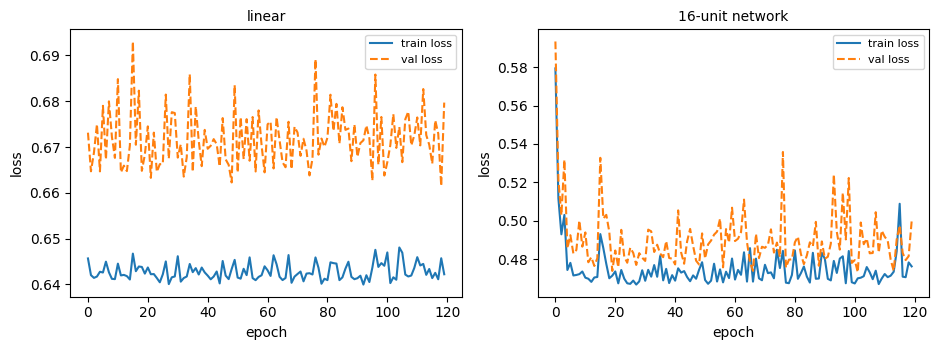

In [52]:
# Plot loss rather than accuracy: loss moves smoothly and reacts earlier.
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
for ax, (hist, name) in zip(axes, [(linear_hist, "linear"), (net_hist, "16-unit network")]):
    ax.plot(hist["train_loss"], label="train loss")
    ax.plot(hist["val_loss"], label="val loss", linestyle="--")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Lab 2.4 Overfitting, on purpose

Overfitting is easiest to see when you starve the model of data. Here is a 128-unit network on
**150 rows**.

Watch it reach 100% on the training set. It has not learned the rule — it has memorised 150 answers,
including the coin-flip noise in them, which is by definition unlearnable. Validation accuracy is
far behind, and that gap is the whole story.

Then the same network with `l2=0.03`. Training accuracy drops, validation accuracy rises. **Being
worse on data you have already seen is the point** — that is what buying generalisation looks like.

In [53]:
# 150 rows against 128+64 hidden units: far more parameters than data points.
tiny_idx = train_idx[:150]
# Refit the scaler on this split - its statistics are its own, not the big split's.
tiny_scaler = Standardizer().fit(X_all[tiny_idx])
X_tiny, y_tiny = tiny_scaler.transform(X_all[tiny_idx]), y_all[tiny_idx]
X_val_tiny = tiny_scaler.transform(X_all[val_idx])

for l2 in (0.0, 0.03):
    params, _ = fit(X_tiny, y_tiny, hidden=(128, 64), epochs=300, lr=0.1, l2=l2)
    train_acc = accuracy(params, X_tiny, y_tiny)
    val_acc = accuracy(params, X_val_tiny, y_val)
    label = "no regularisation" if l2 == 0 else f"l2={l2}"
    print(f"{label:20} train {train_acc:.3f}   val {val_acc:.3f}   gap {train_acc - val_acc:+.3f}")


no regularisation    train 1.000   val 0.698   gap +0.302
l2=0.03              train 0.793   val 0.718   gap +0.075


### Exercise C (6 min) — batch size

Smaller batches mean more updates per epoch and noisier gradients. Larger batches mean fewer,
smoother steps. There is no universally right answer; there is a right answer for your data and
your patience.

Run it and note that the number of *epochs* is a misleading way to compare, because an epoch at
`batch_size=16` contains eight times the updates of an epoch at `batch_size=128`.

In [54]:
# TODO: change the batch sizes and compare.
for batch_size in [16, 64, 256]:
    params, hist = fit(X_train, y_train, hidden=(16,), epochs=60, lr=0.1, l2=1e-2,
                       batch_size=batch_size, val=(X_val, y_val))
    # Epochs are held equal, but the number of weight updates is not - that is the confound.
    updates = 60 * int(np.ceil(len(y_train) / batch_size))
    print(f"batch={batch_size:4}  {updates:5} updates  "
          f"train loss {hist['train_loss'][-1]:.4f}  val acc {hist['val_acc'][-1]:.3f}")


batch=  16   6780 updates  train loss 0.4954  val acc 0.788
batch=  64   1740 updates  train loss 0.4804  val acc 0.805
batch= 256    480 updates  train loss 0.4842  val acc 0.797


### Exercise D (6 min) — early stopping

You do not have to accept the last epoch. Validation loss usually bottoms out and then climbs; the
epoch where it bottoms is the model you actually want.

Find it in the history and compare it to where training left you.

In [55]:
params, hist = fit(X_train, y_train, hidden=(32, 16), epochs=250, lr=0.1, val=(X_val, y_val))

# argmin over the recorded history - finding the best epoch needs no retraining.
best_epoch = int(np.argmin(hist["val_loss"]))
print(f"best epoch by val loss : {best_epoch + 1} of 250")
print(f"  val loss there       : {hist['val_loss'][best_epoch]:.4f}  "
      f"(val acc {hist['val_acc'][best_epoch]:.3f})")
print(f"  val loss at the end  : {hist['val_loss'][-1]:.4f}  "
      f"(val acc {hist['val_acc'][-1]:.3f})")
print(f"  train loss meanwhile : {hist['train_loss'][best_epoch]:.4f} -> "
      f"{hist['train_loss'][-1]:.4f}  (still improving, which is the trap)")


best epoch by val loss : 12 of 250
  val loss there       : 0.3950  (val acc 0.835)
  val loss at the end  : 0.5331  (val acc 0.800)
  train loss meanwhile : 0.3679 -> 0.3017  (still improving, which is the trap)


### Lab 2 checkpoint

1. Split, then scale — statistics come from training rows only
2. The floor and the ceiling frame every number; raw accuracy alone says little
3. Learning curves diagnose what to change; a final score does not
4. A network that hits 100% on training data is usually memorising, noise included
5. Regularisation and early stopping both trade training fit for generalisation

---

# Lab 3 — Evaluate honestly (20 min)

Training a network is the easy part. Knowing whether it is any good, and being able to defend that
claim, is the part that decides whether it ships.

## Lab 3.1 Accuracy hides things

Accuracy is one number summarising two very different mistakes. Predicting "will sell" for a
listing that does not is a wasted expectation; missing one that would have sold is a lost
opportunity. They are not interchangeable, and accuracy cannot tell them apart.

The threshold sweep below is the important part. The trained network never changes — only where we
cut the probability. Precision and recall move in opposite directions, and picking the cut is a
business decision, not a modelling one.

In [56]:
# Validation, not test: we are still making decisions, so test stays sealed.
print("network on the validation split, at the default 0.5 cut:")
cm = confusion(net_params, X_val, y_val)
print(f"  predicted sell, sold      (tp) {cm['tp']:5.0f}")
print(f"  predicted sell, did not   (fp) {cm['fp']:5.0f}")
print(f"  predicted no sell, sold   (fn) {cm['fn']:5.0f}")
print(f"  predicted no sell, right  (tn) {cm['tn']:5.0f}")
print(f"  precision {cm['precision']:.3f}   recall {cm['recall']:.3f}")

print("\nsame model, different cut:")
print(f"{'threshold':>10} {'accuracy':>9} {'precision':>10} {'recall':>8}")
for t in (0.3, 0.4, 0.5, 0.6, 0.7):
    c = confusion(net_params, X_val, y_val, threshold=t)
    print(f"{t:>10.1f} {accuracy(net_params, X_val, y_val, threshold=t):>9.3f} "
          f"{c['precision']:>10.3f} {c['recall']:>8.3f}")


network on the validation split, at the default 0.5 cut:
  predicted sell, sold      (tp)   270
  predicted sell, did not   (fp)    39
  predicted no sell, sold   (fn)    76
  predicted no sell, right  (tn)   215
  precision 0.874   recall 0.780

same model, different cut:
 threshold  accuracy  precision   recall
       0.3     0.812      0.781    0.936
       0.4     0.828      0.833    0.879
       0.5     0.808      0.874    0.780
       0.6     0.753      0.884    0.659
       0.7     0.693      0.897    0.529


## Lab 3.2 Capacity and regularisation sweep

One configuration is an anecdote. This sweeps width against `l2` and reports validation accuracy
**and the train–validation gap**, which is the part people leave out.

Read the two columns on the right, not just the middle one:

- **One unit underfits.** It cannot represent the hump, so it stalls well short of the ceiling.
- **Two units are enough.** Validation accuracy is already at the ceiling. Everything wider is
  spending parameters on nothing.
- **The widest network is the worst on validation** while being the best on training — a `+0.067`
  gap. That is memorisation, priced exactly.
- **`l2` closes the gap.** It costs the wide network training accuracy and hands back validation
  accuracy, landing it roughly where the 2-unit model already was.

The uncomfortable conclusion is the useful one: on this problem the right architecture is small, and
you would only ever find that out by measuring.

In [57]:
print(f"{'hidden':>12} {'l2':>6} {'train':>7} {'val':>7} {'gap':>7}")
sweep = {}  # keep each trained model so the next cell can pick a winner
for hidden in [(1,), (2,), (16,), (64, 32)]:
    for l2 in (0.0, 1e-2):
        params, _ = fit(X_train, y_train, hidden=hidden, epochs=120, lr=0.1, l2=l2,
                        val=(X_val, y_val))
        train_acc = accuracy(params, X_train, y_train)
        val_acc = accuracy(params, X_val, y_val)
        sweep[(hidden, l2)] = (params, val_acc)
        print(f"{str(hidden):>12} {l2:>6} {train_acc:>7.3f} {val_acc:>7.3f} "
              f"{train_acc - val_acc:>+7.3f}")


      hidden     l2   train     val     gap
        (1,)    0.0   0.678   0.705  -0.027
        (1,)   0.01   0.673   0.690  -0.017
        (2,)    0.0   0.798   0.817  -0.018
        (2,)   0.01   0.809   0.817  -0.008
       (16,)    0.0   0.822   0.812  +0.011
       (16,)   0.01   0.809   0.808  +0.001
    (64, 32)    0.0   0.859   0.792  +0.067
    (64, 32)   0.01   0.810   0.818  -0.008


## Lab 3.3 Read the test set once

Pick the winner on validation, then look at test — one time.

Expect test to come in **below** validation. That is not a bug and not bad luck: you chose this
configuration *because* it scored well on validation, so that score includes some luck you cannot
take with you. The gap between the two is the price of tuning, and reporting the validation number
as your result is the most common way honest people overstate a model.

In [58]:
# Chosen on validation accuracy alone - which is exactly what makes that number optimistic.
best_key = max(sweep, key=lambda k: sweep[k][1])
best_params, best_val = sweep[best_key]

print(f"chosen on validation : hidden={best_key[0]}, l2={best_key[1]}  (val {best_val:.3f})")
print(f"test accuracy        : {accuracy(best_params, X_test, y_test):.3f}   <- the honest number")
print(f"floor / ceiling      : {majority:.3f} / {bayes:.3f}")


chosen on validation : hidden=(64, 32), l2=0.01  (val 0.818)
test accuracy        : 0.790   <- the honest number
floor / ceiling      : 0.544 / 0.822


## Lab 3.4 Did it actually learn the rule?

The payoff for generating our own data. We can hold three features fixed, sweep the fourth, and
compare what the network believes against the probability we *actually* generated labels from.

Look for two things:

- the **hump** — probability peaks near a fair price and falls off in both directions, which no
  linear model can produce
- the **interaction** — the shape is different at 30k miles than at 110k miles

You will also see it is not exact — at 110k miles and 6% below guide it says 0.45 where the truth is
0.65. The edges of the input space are where training data is thinnest and the errors are largest.
That is the honest picture: the network recovered the structure, not the formula.

In [59]:
def true_probability(price_gap, mileage_k, photos=12.0, condition=3.0):
    """The generating rule from Part B, so we can compare against ground truth."""
    # Same arithmetic as make_listings, on raw (unstandardised) feature values.
    pg, mk = price_gap / 6, (mileage_k - 60) / 30
    ph, cd = (photos - 12) / 7, (condition - 3) / 1.4
    return float(sigmoid(np.array(
        2.2 - 2.6 * pg**2 - 1.0 * mk + 0.9 * ph + 0.7 * cd - 1.6 * pg * mk)))


print("p(sells within 30 days), 12 photos, condition 3")
for mileage in (30.0, 110.0):
    print(f"\n  mileage {mileage:.0f}k")
    print(f"  {'price gap':>10} {'network':>9} {'true':>7}")
    for gap in (-12, -6, 0, 6, 12):
        # One synthetic row at a time. scaler.transform is required: the network was
        # trained on standardised inputs and knows nothing about raw units.
        row = np.array([[gap, mileage, 12.0, 3.0]])
        modelled = float(predict_proba(best_params, scaler.transform(row))[0])
        print(f"  {gap:>+10} {modelled:>9.2f} {true_probability(gap, mileage):>7.2f}")


p(sells within 30 days), 12 photos, condition 3

  mileage 30k
   price gap   network    true
         -12      0.01    0.00
          -6      0.30    0.27
          +0      0.92    0.96
          +6      0.83    0.90
         +12      0.17    0.02

  mileage 110k
   price gap   network    true
         -12      0.02    0.01
          -6      0.45    0.65
          +0      0.73    0.63
          +6      0.10    0.01
         +12      0.01    0.00


### Exercise E (6 min) — your own probe

Pick a feature and a question you would actually be asked — "does adding photos help a
high-mileage car?" — then probe the model and compare with `true_probability`.

Two habits worth building here: change one input at a time, and check whether the region you are
probing had any training data in it at all. The cell prints that count, and the disagreement it
explains is the most instructive output in the lab — the network is confidently wrong about
low-photo, high-mileage listings because it saw very few of them.

In [60]:
# TODO: change the feature you sweep and the fixed values.
print(f"{'photos':>8} {'network':>9} {'true':>7}   (price at guide, 110k miles)")
for photos in (2, 8, 14, 20):
    row = np.array([[0.0, 110.0, float(photos), 3.0]])
    modelled = float(predict_proba(best_params, scaler.transform(row))[0])
    print(f"{photos:>8} {modelled:>9.2f} "
          f"{true_probability(0.0, 110.0, photos=photos):>7.2f}")

# How much data did the model actually have in that corner?
sparse_region = (X_all[train_idx, 1] > 90) & (X_all[train_idx, 2] < 5)
print(f"\ntraining rows with mileage > 90k AND fewer than 5 photos: "
      f"{int(sparse_region.sum())} of {len(train_idx)}")


  photos   network    true   (price at guide, 110k miles)
       2      0.67    0.32
       8      0.70    0.50
      14      0.74    0.69
      20      0.77    0.83

training rows with mileage > 90k AND fewer than 5 photos: 44 of 1800


### Lab 3 checkpoint

1. Accuracy summarises two different mistakes; look at precision and recall separately
2. The decision threshold is yours to choose, and it is not a modelling question
3. Sweep configurations rather than trusting one run, and report the gap alongside the score
4. Validation picks the model, test estimates performance, and test comes in lower
5. Probing a model against known truth tells you *what* it learned, not just how well

---

# Wrap

What you built, in about 110 lines of numpy:

1. **Initialization** — random, He-scaled, because identical weights never differentiate
2. **Forward** — affine transform, nonlinearity, repeat; logits out
3. **Loss** — cross-entropy, computed on logits so it cannot overflow
4. **Backward** — prediction minus truth at the output, then the chain rule backwards
5. **Update** — mini-batch steps with momentum
6. **Evaluation** — floor, ceiling, curves, threshold, sweep, test once

The whole of deep learning is variations on these six things. Convolutions change what a layer
computes. Transformers change how layers attend to their inputs. Adam changes step 5. None of them
change the loop.

## Where this notebook is a toy, on purpose

- **Binary classification only.** Multi-class means a softmax output and cross-entropy over
  several logits — a change to A.3 and A.5, not to the loop.
- **Plain momentum SGD.** No Adam, no learning-rate schedule, no batch norm, no dropout. Each of
  those is a small, well-defined addition to `fit()`.
- **Small and synthetic.** 3,000 generated rows with a rule we chose. Real data brings missing
  values, leakage, drift, imbalance, and labels that are themselves wrong.
- **We know the ceiling.** That is the single biggest difference from real work. You will not know
  how much headroom is left, which is exactly why baselines and held-out data matter so much more
  out there.
- **`fit()` uses all your rows every epoch and never stops early on its own.** Exercise D shows you
  the epoch you wanted; production code would track it and stop.

For real work: use a framework, keep the test set sealed, compare against a stupid baseline before
anything else, and write down the metric you are optimising before you start training. The loop
above is what those frameworks are doing underneath.